# 02 — Feature Extraction

**Music Genre & Composer Classification (Bach · Beethoven · Chopin · Mozart)**

This notebook converts each cleaned MIDI file into the two numerical tensor
representations consumed by the deep-learning models in
`03_model_building_and_evaluation.ipynb`:

| Representation | Shape (per excerpt) | Feeds | Captures |
|---|---|---|---|
| **Piano-roll matrix** | `128 × 128` (pitch × time) | **CNN** | local spatial texture — chord voicings, parallel motion, density |
| **Encoded note sequence** | `128 × 3` (pitch, dur, ioi) | **LSTM** | strict temporal order — motifs, phrasing, long-range structure |
| **Word2Vec document vector** | `100` | **classical / hybrid branch** | global harmonic-vocabulary fingerprint (carried from notebook 01) |

**Design in one line.** Every MIDI file is placed on a *tempo-normalised
16th-note grid* and sliced into fixed-length **overlapping time windows
("excerpts")**. Each window produces the piano-roll **and** the note sequence
from the *same* slice of music, so the CNN and LSTM datasets are **row-aligned**
— which is what lets a hybrid ensemble fuse them per sample.

### Relationship to the other notebooks
- **`01_data_preprocessing.ipynb`** downloaded the corpus, chose the working
  file set (≤80 files/composer), and produced NLP-style vectorisations
  (Bag-of-Words / TF-IDF / **Word2Vec**). Those are *document-level* vectors and
  cannot feed a CNN or LSTM directly. This notebook therefore **re-parses the
  raw MIDI** for the sequential/spatial tensors, while **carrying the Word2Vec
  vectors forward** (aligned by file) as a third, complementary feature set.
- **`03_model_building_and_evaluation.ipynb`** loads the cached tensors from
  `data/processed/` and trains the CNN, LSTM, and hybrid models.

> **Data location.** This notebook reads raw MIDI from `data/raw/` and writes
> cached tensors to `data/processed/`. If you have not yet populated
> `data/raw/`, run notebook 01 (or download the Kaggle
> `blanderbuss/midi-classic-music` dataset into `data/raw/`) first.


## 1. Environment & configuration

All tunable knobs live in the config cell below so the whole extraction is
reproducible and easy to sweep. `pretty_midi` does the note-level parsing;
`music21` is used for higher-level harmonic analysis (key estimation) in the
EDA section; `mido` is imported as a low-level fallback.


In [12]:
# ---------------------------------------------------------------------------
# 1.1 Package installation (safe to re-run; no-op if already installed)
# ---------------------------------------------------------------------------
import sys, subprocess
def pip_install(packages):
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", *packages])

# Uncomment on a fresh environment (e.g. Kaggle/Colab):
# pip_install(["pretty_midi", "music21", "mido"])

# ---------------------------------------------------------------------------
# 1.2 Imports
# ---------------------------------------------------------------------------
import os, glob, json, pickle, warnings
from collections import Counter, defaultdict

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import pretty_midi
try:
    import music21
    _HAS_MUSIC21 = True
except Exception:
    _HAS_MUSIC21 = False
try:
    import mido           # low-level fallback (imported for completeness)
    _HAS_MIDO = True
except Exception:
    _HAS_MIDO = False

warnings.filterwarnings("ignore")
np.random.seed(42)
print("pretty_midi", pretty_midi.__version__,
      "| music21", (getattr(music21, "__version__", "?") if _HAS_MUSIC21 else "MISSING"),
      "| mido", ("loaded" if _HAS_MIDO else "MISSING"))


pretty_midi 0.2.11.post0 | music21 10.5.0 | mido loaded


In [13]:
# ---------------------------------------------------------------------------
# 1.3 Configuration — every extraction knob in one place
# ---------------------------------------------------------------------------
SEED = 42
COMPOSERS = ["Bach", "Beethoven", "Chopin", "Mozart"]   # fixed label order

# --- paths ---
RAW_DIR       = "data/raw"
PROCESSED_DIR = "data/processed"
os.makedirs(PROCESSED_DIR, exist_ok=True)

# Where notebook 01 may have written its handoff artifacts. We search these
# directories (first hit wins) so this notebook runs whether nb01 saved to the
# repo root, the notebooks/ folder, data/processed/, or the current dir.
ARTIFACT_SEARCH_DIRS = [".", "..", "notebooks", PROCESSED_DIR, RAW_DIR,
                        os.path.join("..", PROCESSED_DIR)]

# --- symbolic time grid ---
PITCH_DIM      = 128       # MIDI pitch range 0-127
STEPS_PER_BEAT = 4         # 16th-note resolution (4 sixteenths per quarter note)
DEFAULT_TEMPO  = 120.0     # fallback BPM when tempo cannot be estimated

# --- windowing (defines one training "excerpt") ---
PR_WINDOW   = 128          # time-steps per excerpt (= 8 bars of 16ths in 4/4)
PR_HOP      = 64           # hop between windows (50% overlap = light augmentation)
MAX_WINDOWS = 40           # cap windows per file (stops long pieces dominating)
SEQ_LEN     = 128          # max notes per excerpt (pad/truncate to this)

# --- duration / inter-onset binning (right edges, in 16th-note units) ---
DUR_BINS = np.array([0.5, 1, 2, 3, 4, 6, 8, 12, 16, 24, 32], dtype=np.float32)
IOI_BINS = np.array([0.25, 0.5, 1, 2, 3, 4, 6, 8, 12, 16, 24, 32], dtype=np.float32)

# integer-encoding: pad tokens sit one past the largest real index per channel
PITCH_PAD = 128                     # pitch channel: 0-127 real, 128 = pad
DUR_PAD   = len(DUR_BINS) + 1       # digitize -> 0..len(DUR_BINS); +1 = pad
IOI_PAD   = len(IOI_BINS) + 1
PAD_VEC   = np.array([PITCH_PAD, DUR_PAD, IOI_PAD], dtype=np.int64)

PITCH_VOCAB = PITCH_PAD + 1         # 129 — embedding input_dim for pitch
DUR_VOCAB   = DUR_PAD + 1           # duration channel vocab size
IOI_VOCAB   = IOI_PAD + 1           # ioi channel vocab size

print(f"Excerpt = {PR_WINDOW} sixteenth-steps  |  piano-roll {PITCH_DIM}x{PR_WINDOW}"
      f"  |  sequence {SEQ_LEN}x3")
print(f"Embedding vocab sizes  ->  pitch:{PITCH_VOCAB}  dur:{DUR_VOCAB}  ioi:{IOI_VOCAB}")


Excerpt = 128 sixteenth-steps  |  piano-roll 128x128  |  sequence 128x3
Embedding vocab sizes  ->  pitch:129  dur:13  ioi:14


## 2. Load the working file set & Word2Vec vectors from notebook 01

Notebook 01 fixed the exact list of files (≤80/composer) and their labels, and
trained Word2Vec on them. To keep every downstream representation **row-aligned
with those labels**, we load that same file list here. Two artifacts are used:

- `preprocessed_corpus.pkl` → `filepaths`, `labels` (the canonical sample order)
- `vectorized_dense_features.npz` → `X_w2v_cbow` (100-d per file), `composer_classes`

If those artifacts are not found, the notebook **falls back** to rediscovering
MIDI files under `data/raw/` with the same 80-files/composer cap and seed, and
simply skips the Word2Vec branch (filled with zeros, with a warning).


In [14]:
# ---------------------------------------------------------------------------
# 2.1 Artifact discovery helper
# ---------------------------------------------------------------------------
def find_artifact(filename, search_dirs=ARTIFACT_SEARCH_DIRS):
    for d in search_dirs:
        cand = os.path.join(d, filename)
        if os.path.exists(cand):
            return cand
    return None

def resolve_midi_path(stored_path):
    # Make a filepath saved by nb01 resolve on this machine: try as-is, then
    # relocate by basename under RAW_DIR (handles different working dirs).
    if os.path.exists(stored_path):
        return stored_path
    base = os.path.basename(stored_path)
    hits = glob.glob(os.path.join(RAW_DIR, "**", base), recursive=True)
    return hits[0] if hits else None


In [15]:
# ---------------------------------------------------------------------------
# 2.2 Rediscovery fallback (mirrors nb01's discover + 80/composer cap)
# ---------------------------------------------------------------------------
MAX_FILES_PER_COMPOSER = 80

def discover_midi_files(root_dir, composers):
    paths  = glob.glob(os.path.join(root_dir, "**", "*.mid"),  recursive=True)
    paths += glob.glob(os.path.join(root_dir, "**", "*.midi"), recursive=True)
    rows = []
    for p in paths:
        lp = p.lower()
        for c in composers:
            if c.lower() in lp:
                rows.append({"filepath": p, "composer": c})
                break
    return pd.DataFrame(rows)

def rediscover_sample_set():
    df = discover_midi_files(RAW_DIR, COMPOSERS)
    if df.empty:
        raise FileNotFoundError(
            f"No MIDI files found under '{RAW_DIR}'. Populate it (run nb01 or "
            f"download the Kaggle dataset) before running feature extraction.")
    # capped stratified sample, written to be robust across pandas versions
    parts = [g.sample(min(len(g), MAX_FILES_PER_COMPOSER), random_state=SEED)
             for _, g in df.groupby("composer")]
    df = pd.concat(parts).reset_index(drop=True)
    return df["filepath"].tolist(), df["composer"].tolist(), None


In [16]:
# ---------------------------------------------------------------------------
# 2.3 Load canonical sample set + Word2Vec vectors (with graceful fallback)
# ---------------------------------------------------------------------------
corpus_pkl = find_artifact("preprocessed_corpus.pkl")
w2v_npz    = find_artifact("vectorized_dense_features.npz")

filepaths, labels, w2v_by_file = None, None, None

if corpus_pkl is not None:
    with open(corpus_pkl, "rb") as f:
        corpus = pickle.load(f)
    filepaths = list(corpus["filepaths"])
    labels    = [str(l) for l in corpus["labels"]]
    print(f"Loaded {len(filepaths)} files from nb01 handoff: {corpus_pkl}")

    if w2v_npz is not None:
        dense = np.load(w2v_npz, allow_pickle=True)
        X_w2v = dense["X_w2v_cbow"]                     # (n_files, 100), nb01 order
        if X_w2v.shape[0] == len(filepaths):
            w2v_by_file = {fp: X_w2v[i] for i, fp in enumerate(filepaths)}
            print(f"Loaded Word2Vec (CBOW) vectors {X_w2v.shape} from {w2v_npz}")
        else:
            print(f"[warn] W2V rows ({X_w2v.shape[0]}) != files ({len(filepaths)});"
                  " skipping W2V branch.")
    else:
        print("[warn] vectorized_dense_features.npz not found; skipping W2V branch.")
else:
    print("[warn] nb01 handoff not found — rediscovering files from data/raw.")
    filepaths, labels, w2v_by_file = rediscover_sample_set()
    print(f"Rediscovered {len(filepaths)} files under {RAW_DIR}.")

# --- Reconcile class set with whatever nb01 (or the data) actually used --------
# nb01 may have used short/lowercase tags (e.g. 'beeth' for Beethoven). Adopt the
# labels actually present so every downstream array stays aligned; keep a
# friendly display map for plots and the report.
labels = [str(l) for l in labels]
observed = sorted(set(labels))
if sorted(c.lower() for c in COMPOSERS) != sorted(o.lower() for o in observed):
    print(f"[info] Adopting class set & order from data: {observed}  (was {COMPOSERS})")
    COMPOSERS = observed

_FRIENDLY = {"bach": "Bach", "beeth": "Beethoven", "beethoven": "Beethoven",
             "chopin": "Chopin", "mozart": "Mozart"}
COMPOSER_DISPLAY = {c: _FRIENDLY.get(c.lower(), c.title()) for c in COMPOSERS}

W2V_DIM = (next(iter(w2v_by_file.values())).shape[0]) if w2v_by_file else 100
print(f"Word2Vec branch: {'ENABLED' if w2v_by_file else 'disabled (zeros)'}"
      f"  (dim={W2V_DIM})  |  classes: {[COMPOSER_DISPLAY[c] for c in COMPOSERS]}")
pd.Series(labels).value_counts().reindex(COMPOSERS)


Loaded 211 files from nb01 handoff: ./preprocessed_corpus.pkl
Loaded Word2Vec (CBOW) vectors (211, 100) from ./vectorized_dense_features.npz
[info] Adopting class set & order from data: ['bach', 'beeth', 'chopin', 'mozart']  (was ['Bach', 'Beethoven', 'Chopin', 'Mozart'])
Word2Vec branch: ENABLED  (dim=100)  |  classes: ['Bach', 'Beethoven', 'Chopin', 'Mozart']


bach      70
beeth     42
chopin    43
mozart    56
Name: count, dtype: int64

## 3. MIDI parsing layer

Each file's instrument tracks are flattened into a single ordered list of note
events `(onset, offset, pitch, velocity)`. Drum tracks are dropped (unpitched);
**overlapping notes are kept** so simultaneous/chordal structure survives.
Tempo is resolved best-effort so the time grid is musically meaningful rather
than tied to wall-clock seconds.


In [17]:
# ---------------------------------------------------------------------------
# 3.1 Note-event extraction and tempo resolution
# ---------------------------------------------------------------------------
def extract_note_events(pm):
    # Flatten non-drum tracks into an ordered [(start,end,pitch,vel), ...].
    notes = []
    for inst in pm.instruments:
        if inst.is_drum:
            continue
        for n in inst.notes:
            if n.end > n.start and 0 <= n.pitch < PITCH_DIM:
                notes.append((float(n.start), float(n.end),
                              int(n.pitch), int(n.velocity)))
    notes.sort(key=lambda x: (x[0], x[2]))
    return notes

def get_tempo(pm):
    # Best-effort single tempo (BPM) with graceful fallbacks.
    try:
        _, tempi = pm.get_tempo_changes()
        if len(tempi) and tempi[0] > 0:
            return float(tempi[0])
    except Exception:
        pass
    try:
        t = pm.estimate_tempo()
        if t and t > 0:
            return float(t)
    except Exception:
        pass
    return DEFAULT_TEMPO


## 4. Extracted musical parameters (report §5.2)

For transparency and EDA we compute a per-file **musical parameter summary**:
pitch range & register, note-duration statistics, velocity/dynamics, chord
density (simultaneous-note groups), tempo and time signature. These describe the
corpus and motivate the two tensor designs; they are not fed to the nets
directly (except tempo/time, which shape the grid).


In [18]:
# ---------------------------------------------------------------------------
# 4.1 Per-file musical-parameter summary
# ---------------------------------------------------------------------------
def musical_parameter_summary(pm, notes, bpm):
    pitches    = np.array([n[2] for n in notes])
    velocities = np.array([n[3] for n in notes])
    durations  = np.array([n[1] - n[0] for n in notes])

    # chord structure: group notes sharing (near-)identical onset
    onsets = np.array([round(n[0], 3) for n in notes])
    groups = Counter(onsets)
    n_chords = sum(1 for v in groups.values() if v >= 2)

    ts = pm.time_signature_changes
    ts_str = f"{ts[0].numerator}/{ts[0].denominator}" if ts else "n/a"

    return {
        "n_notes":       len(notes),
        "pitch_min":     int(pitches.min()),
        "pitch_max":     int(pitches.max()),
        "pitch_range":   int(pitches.max() - pitches.min()),
        "mean_velocity": float(velocities.mean()),
        "mean_dur_s":    float(durations.mean()),
        "n_chords":      n_chords,
        "chord_ratio":   float(n_chords / max(len(groups), 1)),
        "tempo_bpm":     float(bpm),
        "time_sig":      ts_str,
    }


## 5. Piano-roll representation — CNN input (report §5.3)

A **velocity-weighted** matrix of shape `128 × T`: rows are MIDI pitches,
columns are 16th-note time-steps. `roll[p, t]` = loudness (velocity ÷ 127) of
pitch `p` sounding at step `t`, else 0. Building it on a **tempo-normalised**
16th-note grid (rather than raw seconds) makes fast and slow performances of the
same music comparable — the CNN sees consistent spatial patterns regardless of
absolute tempo. This is image-like input ideal for convolutional filters that
detect chord voicings, parallel motion and textural density.


In [19]:
# ---------------------------------------------------------------------------
# 5.1 Build a velocity-weighted piano roll on the 16th-note grid
# ---------------------------------------------------------------------------
def build_piano_roll(notes, bpm):
    sec_per_step = 60.0 / bpm / STEPS_PER_BEAT
    if not notes:
        return np.zeros((PITCH_DIM, 0), dtype=np.float32), sec_per_step
    total_end = max(n[1] for n in notes)
    T = int(np.ceil(total_end / sec_per_step)) + 1
    roll = np.zeros((PITCH_DIM, T), dtype=np.float32)
    for start, end, pitch, vel in notes:
        s = int(round(start / sec_per_step))
        e = max(int(round(end / sec_per_step)), s + 1)   # >= 1 step
        roll[pitch, s:e] = np.maximum(roll[pitch, s:e], vel / 127.0)
    return roll, sec_per_step

def window_starts(T, window, hop, max_windows):
    # Start indices for fixed-length windows, always covering the tail.
    if T <= window:
        return [0]
    starts = list(range(0, T - window + 1, hop))
    if starts[-1] != T - window:
        starts.append(T - window)
    return starts[:max_windows]


## 6. Note-sequence representation — LSTM input (report §5.3)

An ordered sequence of `(pitch, duration, offset-to-next-onset)` tuples,
**integer-encoded** for an embedding layer:

- **pitch** — MIDI number `0-127` (index `128` = pad)
- **duration** — note length in 16th-note units, bucketed into `DUR_BINS`
- **ioi** — inter-onset interval to the next note (16th-note units), bucketed
  into `IOI_BINS`. An IOI of ~0 marks notes struck together (a chord).

Continuous durations/offsets are **quantised into a small ordinal vocabulary**
so each channel can be embedded, and rhythm generalises across tempi. Each
window is padded/truncated to `SEQ_LEN`; the pad index lets the model mask
padding.


In [20]:
# ---------------------------------------------------------------------------
# 6.1 Encode one window's notes as an integer (pitch, dur_bin, ioi_bin) sequence
# ---------------------------------------------------------------------------
def encode_window_sequence(win_notes, sec_per_step):
    out = np.tile(PAD_VEC, (SEQ_LEN, 1))
    n = min(len(win_notes), SEQ_LEN)
    for i in range(n):
        start, end, pitch, vel = win_notes[i]
        dur_16 = (end - start) / sec_per_step
        if i < len(win_notes) - 1:
            ioi_16 = (win_notes[i + 1][0] - start) / sec_per_step
        else:
            ioi_16 = dur_16
        out[i, 0] = pitch
        out[i, 1] = int(np.digitize(dur_16, DUR_BINS))
        out[i, 2] = int(np.digitize(ioi_16, IOI_BINS))
    return out, n


## 7. Paired-window extraction

`extract_file()` ties everything together: parse → build the full piano roll →
slide fixed-length windows → for each window emit the **paired** piano-roll slice
and note sequence (built from the notes whose onset falls in that window). Both
share the same window, so excerpt *k* of a file has a matching CNN image and
LSTM sequence.


In [21]:
# ---------------------------------------------------------------------------
# 7.1 Per-file extraction -> paired excerpts + parameter summary
# ---------------------------------------------------------------------------
def extract_file(path):
    resolved = resolve_midi_path(path)
    if resolved is None:
        return None, "missing_file"
    try:
        pm = pretty_midi.PrettyMIDI(resolved)
    except Exception:
        return None, "parse_error"

    notes = extract_note_events(pm)
    if not notes:
        return None, "no_notes"

    bpm = get_tempo(pm)
    roll, sec_per_step = build_piano_roll(notes, bpm)
    T = roll.shape[1]
    onset_step = np.array([int(round(n[0] / sec_per_step)) for n in notes])

    prs, seqs, nnotes = [], [], []
    for st in window_starts(T, PR_WINDOW, PR_HOP, MAX_WINDOWS):
        end = st + PR_WINDOW
        pr = np.zeros((PITCH_DIM, PR_WINDOW), dtype=np.float32)
        avail = roll[:, st:end]
        pr[:, :avail.shape[1]] = avail
        idx = np.where((onset_step >= st) & (onset_step < end))[0]
        win_notes = [notes[i] for i in idx]
        seq, k = encode_window_sequence(win_notes, sec_per_step)
        prs.append(pr); seqs.append(seq); nnotes.append(k)

    summary = musical_parameter_summary(pm, notes, bpm)
    return {
        "piano_rolls": np.stack(prs).astype(np.float32),   # (W,128,PR_WINDOW)
        "sequences":   np.stack(seqs).astype(np.int64),    # (W,SEQ_LEN,3)
        "notes_per_window": np.array(nnotes),
        "summary": summary,
    }, "ok"


## 8. Run extraction over the corpus

We iterate the canonical file list, accumulating every excerpt's piano-roll,
sequence, composer label, per-file Word2Vec vector (broadcast to the file's
excerpts), and a **`group` id (the file index)**. The group id is essential:
in notebook 03 the train/test split must be **grouped by file** so that excerpts
from the same piece never straddle the split — otherwise accuracy is inflated by
leakage.


In [22]:
# ---------------------------------------------------------------------------
# 8.1 Extraction loop
# ---------------------------------------------------------------------------
label_to_int = {c: i for i, c in enumerate(COMPOSERS)}

pr_all, seq_all, w2v_all, y_all, grp_all = [], [], [], [], []
file_rows, skipped = [], []

for fidx, (fp, comp) in enumerate(zip(filepaths, labels)):
    result, status = extract_file(fp)
    if status != "ok":
        skipped.append((fp, status))
        continue
    W = result["piano_rolls"].shape[0]
    pr_all.append(result["piano_rolls"])
    seq_all.append(result["sequences"])
    y_all.append(np.full(W, label_to_int[comp], dtype=np.int64))
    grp_all.append(np.full(W, fidx, dtype=np.int64))

    fvec = w2v_by_file.get(fp) if w2v_by_file else None
    if fvec is None:
        fvec = np.zeros(W2V_DIM, dtype=np.float32)
    w2v_all.append(np.tile(fvec.astype(np.float32), (W, 1)))

    row = {"file_index": fidx, "filepath": fp, "composer": comp,
           "n_windows": W, **result["summary"]}
    file_rows.append(row)

    if (fidx + 1) % 25 == 0 or fidx == len(filepaths) - 1:
        print(f"  processed {fidx+1}/{len(filepaths)} files "
              f"| excerpts so far: {sum(len(a) for a in y_all)}")

print(f"\nDone. Files used: {len(file_rows)}  |  skipped: {len(skipped)}")
if skipped:
    print("  skip reasons:", Counter(s for _, s in skipped))


  processed 25/211 files | excerpts so far: 311
  processed 50/211 files | excerpts so far: 577
  processed 75/211 files | excerpts so far: 915
  processed 100/211 files | excerpts so far: 1576
  processed 125/211 files | excerpts so far: 2265
  processed 150/211 files | excerpts so far: 2946
  processed 175/211 files | excerpts so far: 3647
  processed 200/211 files | excerpts so far: 4324
  processed 211/211 files | excerpts so far: 4668

Done. Files used: 210  |  skipped: 1
  skip reasons: Counter({'parse_error': 1})


## 9. Assemble aligned tensors

In [23]:
# ---------------------------------------------------------------------------
# 9.1 Concatenate per-file arrays into row-aligned corpus tensors
# ---------------------------------------------------------------------------
X_pianoroll = np.concatenate(pr_all,  axis=0)     # (N, 128, PR_WINDOW)  float32
X_sequence  = np.concatenate(seq_all, axis=0)     # (N, SEQ_LEN, 3)      int64
X_w2v       = np.concatenate(w2v_all, axis=0)     # (N, W2V_DIM)         float32
y           = np.concatenate(y_all,   axis=0)     # (N,)                 int64
groups      = np.concatenate(grp_all, axis=0)     # (N,)  file index per excerpt

files_df = pd.DataFrame(file_rows)
N = X_pianoroll.shape[0]

assert X_sequence.shape[0] == N == X_w2v.shape[0] == y.shape[0] == groups.shape[0]
print(f"Total excerpts N = {N}  from {files_df.shape[0]} files")
print(f"  X_pianoroll : {X_pianoroll.shape}  {X_pianoroll.dtype}  "
      f"(mem {X_pianoroll.nbytes/1e6:.1f} MB)")
print(f"  X_sequence  : {X_sequence.shape}  {X_sequence.dtype}")
print(f"  X_w2v       : {X_w2v.shape}  {X_w2v.dtype}")
print(f"  y           : {y.shape}   groups: {groups.shape}  "
      f"({len(np.unique(groups))} unique files)")
print("\nPer-class excerpt counts:")
for i, c in enumerate(COMPOSERS):
    print(f"  {COMPOSER_DISPLAY[c]:10s}: {(y==i).sum():5d} excerpts "
          f"from {files_df[files_df.composer==c].shape[0]} files")


Total excerpts N = 4668  from 210 files
  X_pianoroll : (4668, 128, 128)  float32  (mem 305.9 MB)
  X_sequence  : (4668, 128, 3)  int64
  X_w2v       : (4668, 100)  float32
  y           : (4668,)   groups: (4668,)  (210 unique files)

Per-class excerpt counts:
  Bach      :   789 excerpts from 70 files
  Beethoven :  1147 excerpts from 42 files
  Chopin    :  1126 excerpts from 43 files
  Mozart    :  1606 excerpts from 55 files


## 10. EDA & validation

Sanity checks and figures that document the extracted features: class balance,
tempo & key distributions, how full the sequence windows are (padding), and a
visual look at one piano-roll excerpt and its paired note sequence.


In [24]:
# ---------------------------------------------------------------------------
# 10.1 Corpus-level statistics
# ---------------------------------------------------------------------------
pad_frac = (X_sequence[:, :, 0] == PITCH_PAD).mean()
active   = (X_pianoroll > 0).mean()
print(f"Sequence padding fraction : {pad_frac:.1%} "
      f"(lower = denser windows)")
print(f"Piano-roll active-pixel density : {active:.2%}")
print(f"Median notes / excerpt : {np.median([r['n_notes'] for r in file_rows]):.0f} (per file)")
print("\nTempo (BPM) summary:")
print(files_df["tempo_bpm"].describe()[["min","50%","mean","max"]].round(1).to_string())
print("\nTime-signature counts:")
print(files_df["time_sig"].value_counts().head().to_string())


Sequence padding fraction : 11.8% (lower = denser windows)
Piano-roll active-pixel density : 2.48%
Median notes / excerpt : 1558 (per file)

Tempo (BPM) summary:
min      24.0
50%     105.0
mean    114.9
max     460.0

Time-signature counts:
time_sig
4/4    112
3/4     41
2/4     23
6/8     15
3/8      5


In [25]:
# ---------------------------------------------------------------------------
# 10.2 Optional: music21 key estimation on a sample (harmonic EDA)
# ---------------------------------------------------------------------------
if _HAS_MUSIC21 and len(files_df):
    sample = files_df.sample(min(20, len(files_df)), random_state=SEED)
    keys = []
    for _, r in sample.iterrows():
        rp = resolve_midi_path(r["filepath"])
        try:
            k = music21.converter.parse(rp).analyze("key")
            keys.append((r["composer"], f"{k.tonic.name} {k.mode}"))
        except Exception:
            pass
    if keys:
        kd = pd.DataFrame(keys, columns=["composer", "key"])
        print("Estimated keys (sample of files):")
        print(kd.groupby("composer")["key"].apply(
            lambda s: ", ".join(s.value_counts().head(3).index)).to_string())
else:
    print("music21 unavailable — skipping key-estimation EDA.")


Estimated keys (sample of files):
composer
bach      A minor, A major, F major
beeth             E- major, C major
chopin           F# minor, A- major
mozart    C major, G minor, D major


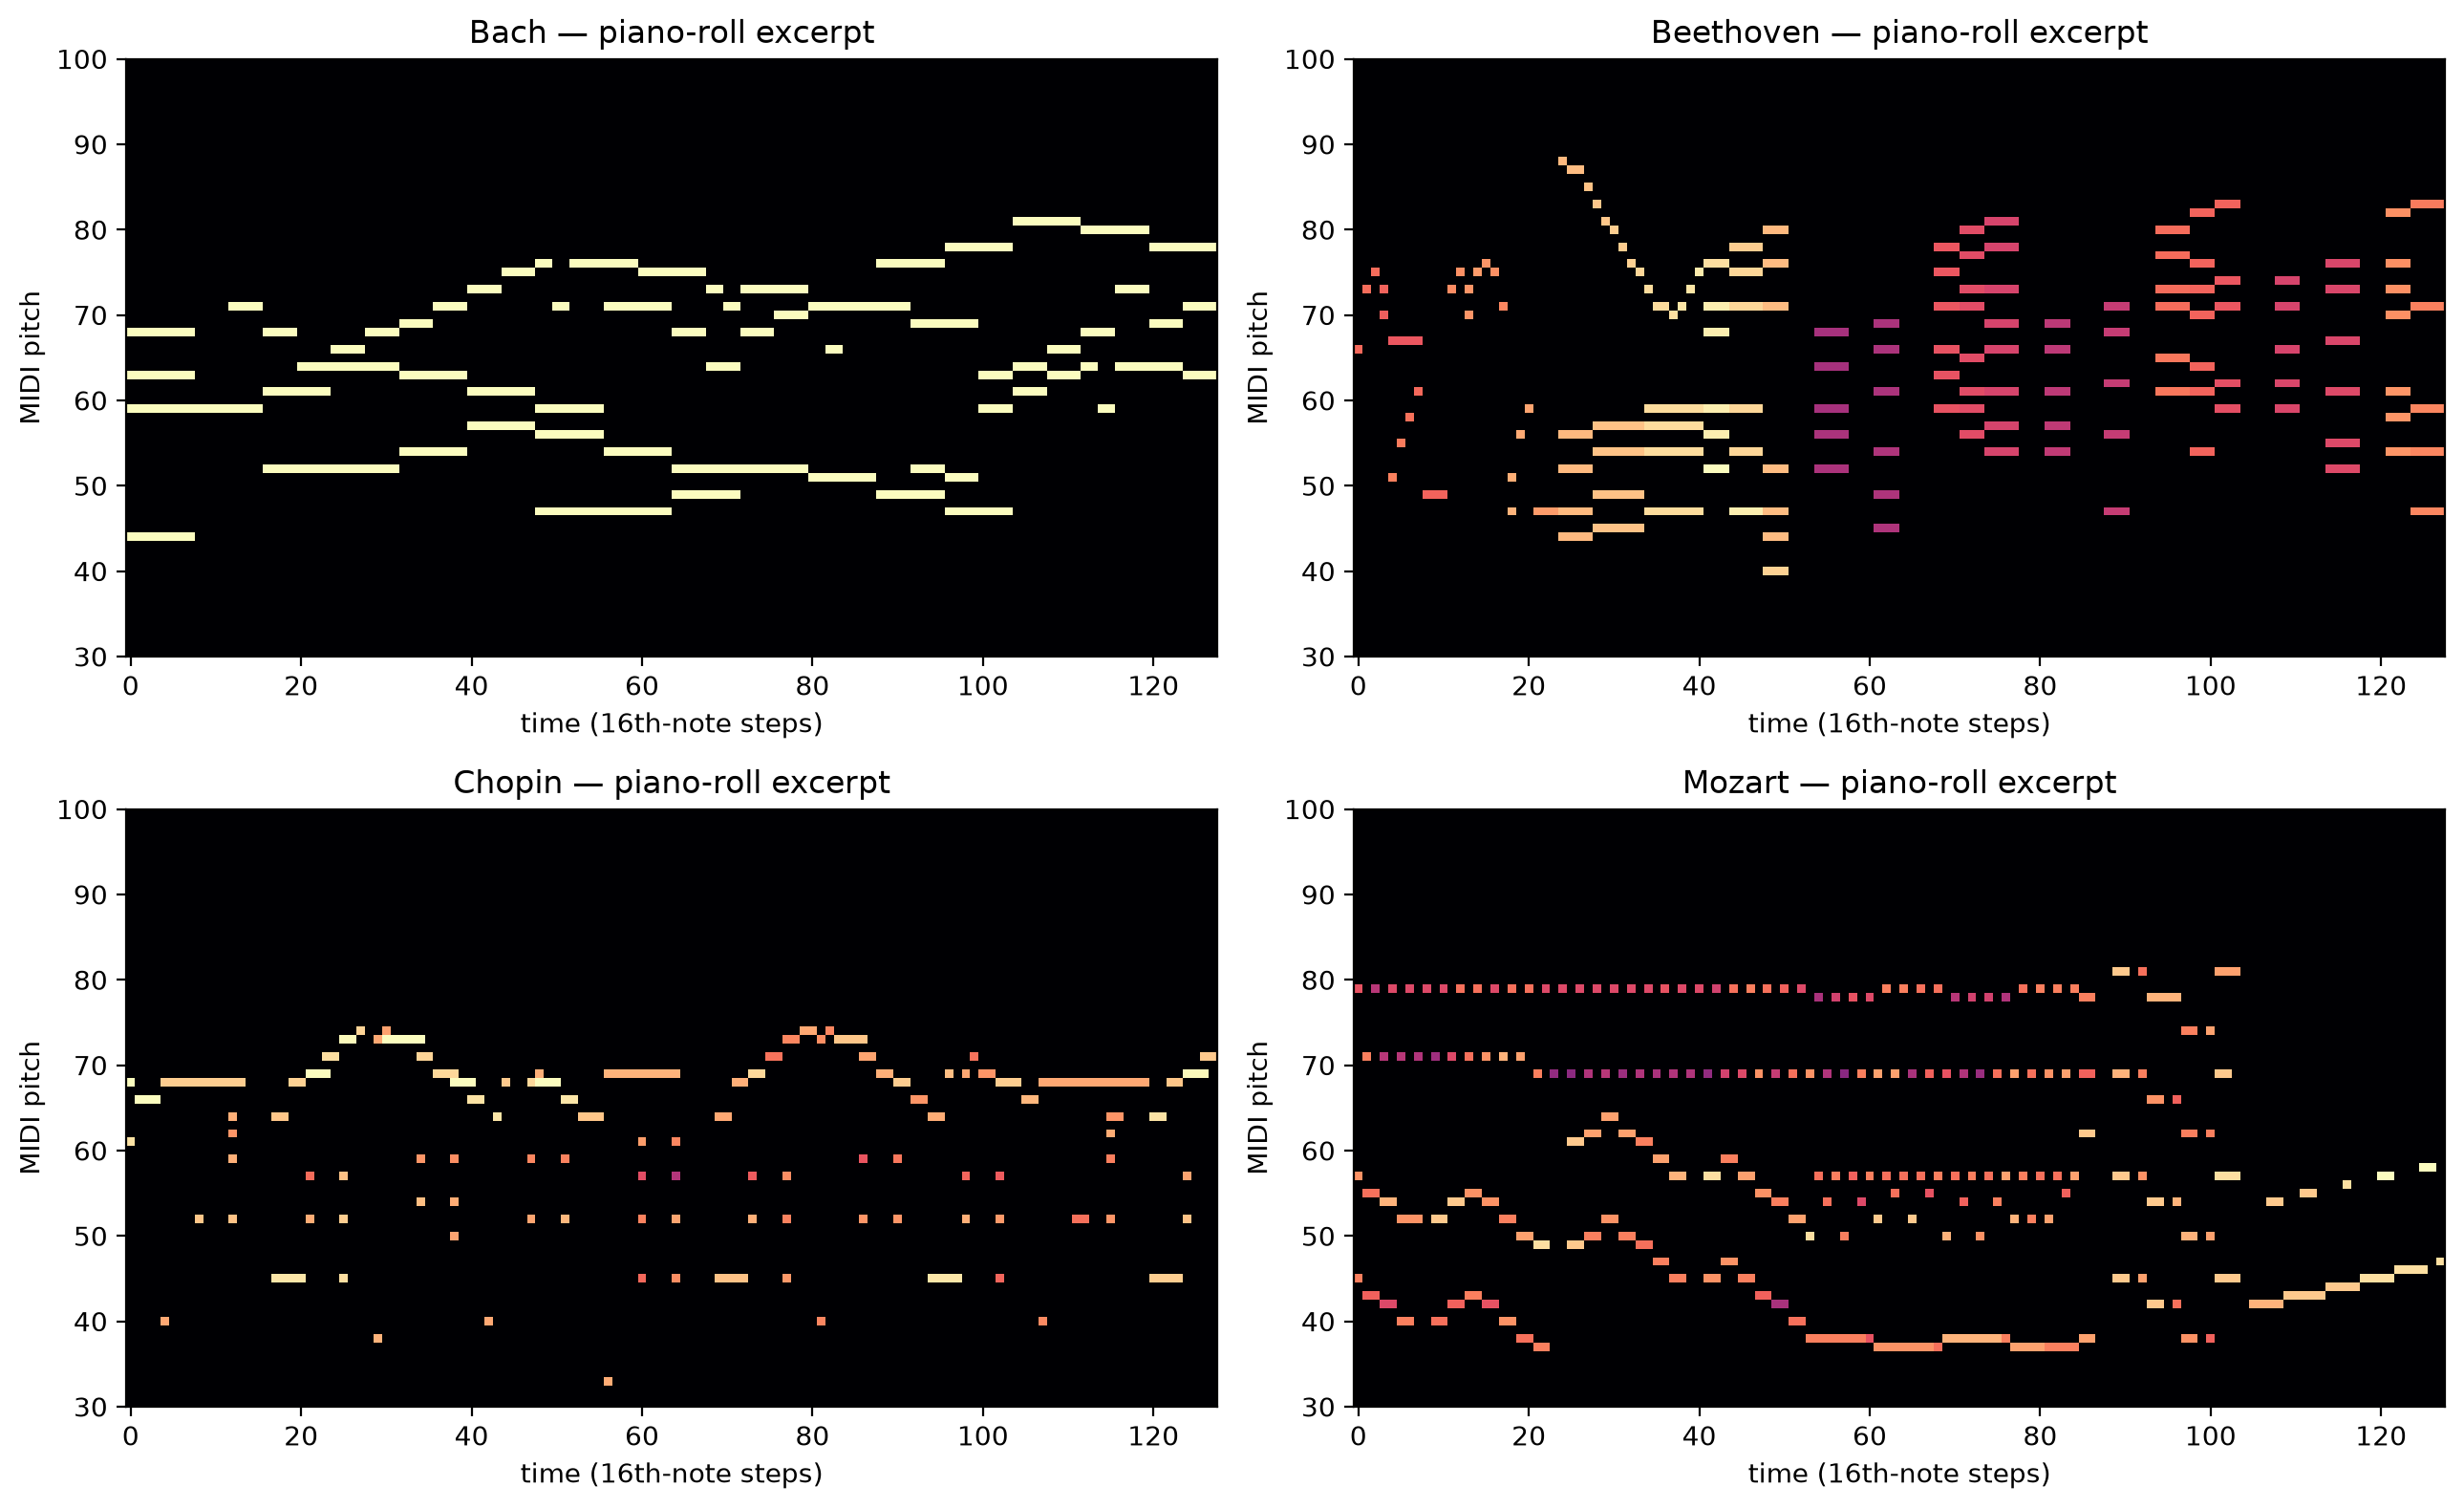

In [26]:
# ---------------------------------------------------------------------------
# 10.3 Visualise one piano-roll excerpt per composer
# ---------------------------------------------------------------------------
fig, axes = plt.subplots(2, 2, figsize=(13, 8))
for ax, comp in zip(axes.ravel(), COMPOSERS):
    idx = np.where(y == label_to_int[comp])[0]
    if len(idx) == 0:
        ax.set_visible(False); continue
    roll = X_pianoroll[idx[len(idx)//2]]          # a middle excerpt
    ax.imshow(roll, aspect="auto", origin="lower", cmap="magma",
              interpolation="nearest")
    ax.set_title(f"{COMPOSER_DISPLAY[comp]} — piano-roll excerpt")
    ax.set_xlabel("time (16th-note steps)"); ax.set_ylabel("MIDI pitch")
    ax.set_ylim(30, 100)                           # focus on the musical register
plt.tight_layout(); plt.show()


In [27]:
# ---------------------------------------------------------------------------
# 10.4 Inspect a paired note sequence (LSTM view) for the same kind of excerpt
# ---------------------------------------------------------------------------
ex = np.where(y == 0)[0][0]
seq = X_sequence[ex]
real = seq[seq[:, 0] != PITCH_PAD]
demo = pd.DataFrame(real[:12], columns=["pitch", "dur_bin", "ioi_bin"])
demo["pitch_name"] = [pretty_midi.note_number_to_name(int(p)) for p in demo["pitch"]]
print(f"Excerpt {ex} ({COMPOSER_DISPLAY[COMPOSERS[y[ex]]]}): {len(real)} real notes, "
      f"{SEQ_LEN-len(real)} pad slots")
demo[["pitch", "pitch_name", "dur_bin", "ioi_bin"]]


Excerpt 0 (Bach): 128 real notes, 0 pad slots


,pitch,pitch_name,dur_bin,ioi_bin
0,62,D4,1,3
1,64,E4,1,3
2,65,F4,1,3
3,67,G4,1,3
4,69,A4,1,3
5,70,A#4,1,2
6,61,C#4,1,2
7,70,A#4,1,3
8,69,A4,1,3
9,67,G4,1,3


## 11. Cache tensors to `data/processed/`

Everything is saved so notebook 03 loads pre-computed features instead of
re-extracting. A single compressed `.npz` holds the arrays; a JSON sidecar
records all config, vocab sizes, bin edges, and class order needed to
reconstruct the modelling setup.


In [28]:
# ---------------------------------------------------------------------------
# 11.1 Save arrays + metadata
# ---------------------------------------------------------------------------
features_path = os.path.join(PROCESSED_DIR, "features.npz")
np.savez_compressed(
    features_path,
    X_pianoroll=X_pianoroll,
    X_sequence=X_sequence,
    X_w2v=X_w2v,
    y=y,
    groups=groups,
    composer_classes=np.array(COMPOSERS),
)

metadata = {
    "composers": COMPOSERS,
    "composer_display": [COMPOSER_DISPLAY[c] for c in COMPOSERS],
    "n_excerpts": int(N),
    "n_files": int(files_df.shape[0]),
    "shapes": {
        "X_pianoroll": list(X_pianoroll.shape),
        "X_sequence":  list(X_sequence.shape),
        "X_w2v":       list(X_w2v.shape),
    },
    "grid": {"pitch_dim": PITCH_DIM, "steps_per_beat": STEPS_PER_BEAT,
             "default_tempo": DEFAULT_TEMPO},
    "windowing": {"pr_window": PR_WINDOW, "pr_hop": PR_HOP,
                  "max_windows": MAX_WINDOWS, "seq_len": SEQ_LEN},
    "sequence_encoding": {
        "channels": ["pitch", "dur_bin", "ioi_bin"],
        "pitch_vocab": PITCH_VOCAB, "dur_vocab": DUR_VOCAB, "ioi_vocab": IOI_VOCAB,
        "pad": {"pitch": PITCH_PAD, "dur": DUR_PAD, "ioi": IOI_PAD},
        "dur_bins": DUR_BINS.tolist(), "ioi_bins": IOI_BINS.tolist(),
    },
    "w2v_branch_enabled": bool(w2v_by_file),
    "w2v_dim": int(W2V_DIM),
}
meta_path = os.path.join(PROCESSED_DIR, "feature_metadata.json")
with open(meta_path, "w") as f:
    json.dump(metadata, f, indent=2)

files_csv = os.path.join(PROCESSED_DIR, "file_summary.csv")
files_df.to_csv(files_csv, index=False)

print("Saved:")
for p in (features_path, meta_path, files_csv):
    print(f"  {p}  ({os.path.getsize(p)/1e6:.2f} MB)")


Saved:
  data/processed/features.npz  (3.36 MB)
  data/processed/feature_metadata.json  (0.00 MB)
  data/processed/file_summary.csv  (0.03 MB)


## 12. Handoff to modelling (`03_...`)

Load features in the next notebook with:

```python
d = np.load("data/processed/features.npz", allow_pickle=True)
X_pianoroll, X_sequence, X_w2v = d["X_pianoroll"], d["X_sequence"], d["X_w2v"]
y, groups = d["y"], d["groups"]
```

**Which array feeds which model**

| Model | Input | Notes |
|---|---|---|
| **CNN** | `X_pianoroll` → add channel dim `(N,128,128,1)` | 2-D convs over pitch×time |
| **LSTM** | `X_sequence` `(N,128,3)` | embed each channel (vocabs in metadata), concat, mask pad |
| **Hybrid** | CNN feats ⊕ LSTM feats ⊕ `X_w2v` | late fusion → dense head |

**Critical:** split with `groups` (e.g. `StratifiedGroupKFold` /
`GroupShuffleSplit`) so no file's excerpts appear in both train and test.
Class counts are mildly imbalanced — use `class_weight` or stratification.

Everything needed downstream now lives in `data/processed/`.
